In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import requests

# Gráficos vectoriales
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# Tokenizador de Eleuther
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-125m')
tokenizer.pad_token_id = tokenizer.encode(' ')[0]

# Cargar dos modelos GPT-neo y enviarlos a la GPU
modelAlice = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m')
modelEdgar = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m')

# -> GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
modelAlice = modelAlice.to(device)
modelEdgar = modelEdgar.to(device)

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# Aventuras de Alicia en el País de las Maravillas
text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
aliceTokens = tokenizer.encode(text, return_tensors='pt')[0]

# Edgar Allan Poe
text = requests.get('https://www.gutenberg.org/cache/epub/2148/pg2148.txt').text
edgarTokens = tokenizer.encode(text, return_tensors='pt')[0]

# Resumen
print(f'Alice in Wonderland has   {len(aliceTokens):7,} tokens.')
print(f'Edgar Allen Poe text has {len(edgarTokens):7,} tokens.')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (52948 > 2048). Running this sequence through the model will result in indexing errors


Alice in Wonderland has    52,948 tokens.
Edgar Allen Poe text has 197,302 tokens.


---

* **Filtrado del corpus de Alice:** Se inicializa un arreglo de NumPy con valores de `-1` del mismo tamaño que los tokens de Alicia, y se recorre cada token para conservar únicamente aquellos cuya longitud decodificada sea mayor a 2 caracteres, descartando partículas muy cortas o signos aislados.
* **Filtrado del corpus de Edgar:** Se repite exactamente el mismo proceso de filtrado de longitud para los tokens de las obras de Edgar Allan Poe, asegurando que ambos datasets mantengan un criterio de limpieza uniforme.

In [4]:
# crear un vector de tokens filtrado inicializado con -1
aliceTokensFilt = np.full(len(aliceTokens), -1, dtype=int)

# copiar el token solo si tiene >2 caracteres
for t in range(len(aliceTokens)):
  if len(tokenizer.decode(aliceTokens[t])) > 2:
    aliceTokensFilt[t] = aliceTokens[t]

# repetir para edgar
edgarTokensFilt = np.full(len(edgarTokens), -1, dtype=int)

# copiar el token solo si tiene >2 caracteres
for t in range(len(edgarTokens)):
  if len(tokenizer.decode(edgarTokens[t])) > 2:
    edgarTokensFilt[t] = edgarTokens[t]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


reporte

Cálculo de tokens descartados: Se utiliza la condición == -1 para contar cuántos elementos fueron filtrados (tokens con menos de 3 caracteres), mostrando tanto la cantidad absoluta como el porcentaje correspondiente sobre el total de tokens.

In [5]:
# informe
print('EDGAR:')
print(
    f' {(edgarTokensFilt==-1).sum():,}/{len(edgarTokensFilt):,} ('
    f' {100*(edgarTokensFilt==-1).sum()/len(edgarTokensFilt):.2f}%) de los'
    ' tokens tienen menos de 3 caracteres.'
)

print('\n\nALICE:')
print(
    f' {(aliceTokensFilt==-1).sum():,}/{len(aliceTokensFilt):,} ('
    f' {100*(aliceTokensFilt==-1).sum()/len(aliceTokensFilt):.2f}%) de los'
    ' tokens tienen menos de 3 caracteres.'
)

EDGAR:
 96,177/197,302 ( 48.75%) de los tokens tienen menos de 3 caracteres.


ALICE:
 24,003/52,948 ( 45.33%) de los tokens tienen menos de 3 caracteres.


## Cuantificar los tokens de los libros

Ignoramos el valor `-1` (empezando el corte desde el índice `1` en lugar de `0` con `freqidx[1:101]`) por una razón técnica clave relacionada con el filtrado previo:

* **Valor de relleno (*placeholder*):** Cuando filtramos los tokens para descartar aquellos con 2 caracteres o menos, no borramos los elementos del arreglo, sino que reemplazamos sus posiciones con `-1`.
* **Frecuencia masiva:** Debido a que una gran cantidad de palabras cortas, signos de puntuación y espacios fueron filtrados, el `-1` pasa a ser, por mucho, el valor que más veces se repite en todo el arreglo (`aliceTokensFilt`).
* **Desplazamiento del ranking:** Si tomáramos el primer elemento (`freqidx[0]`), el "token más frecuente" sería el marcador `-1` en lugar de una palabra real. Al usar el rango `[1:101]`, omitimos ese valor artificial y obtenemos los 100 tokens reales más frecuentes del texto.

In [6]:
# Para Alice
uniq, counts = np.unique(aliceTokensFilt, return_counts=True)
freqidx = np.argsort(counts)[::-1]
top100Alice = uniq[freqidx[1:101]]

# Para Edgar
uniqEdg, countsEdg = np.unique(edgarTokensFilt, return_counts=True)
freqidxEdg = np.argsort(countsEdg)[::-1]
top100Edgar = uniqEdg[freqidxEdg[1:101]]

for t in top100Alice:
  print(
      f"Token {t:5} appears {np.sum(aliceTokensFilt==t):4} times and is"
      f' "{tokenizer.decode(t)}"'
  )

Token   262 appears 1621 times and is " the"
Token   284 appears  763 times and is " to"
Token   290 appears  760 times and is " and"
Token   286 appears  582 times and is " of"
Token   340 appears  504 times and is " it"
Token   673 appears  469 times and is " she"
Token   531 appears  445 times and is " said"
Token   287 appears  396 times and is " in"
Token   345 appears  374 times and is " you"
Token   373 appears  334 times and is " was"
Token 14862 appears  331 times and is " Alice"
Token   326 appears  256 times and is " that"
Token   355 appears  241 times and is " as"
Token   607 appears  233 times and is " her"
Token   351 appears  209 times and is " with"
Token   379 appears  203 times and is " at"
Token   319 appears  190 times and is " on"
Token   477 appears  176 times and is " all"
Token   550 appears  169 times and is " had"
Token   307 appears  161 times and is " be"
Token   329 appears  147 times and is " for"
Token   407 appears  146 times and is " not"
Token   428 a

In [7]:
# Para Edgar
for t in top100Edgar:
  print(
      f'Token {t:5} appears {np.sum(edgarTokensFilt==t):4} times and is'
      f' "{tokenizer.decode(t)}"'
  )

Token   262 appears 6895 times and is " the"
Token   286 appears 4470 times and is " of"
Token   290 appears 2704 times and is " and"
Token   284 appears 2154 times and is " to"
Token   287 appears 1905 times and is " in"
Token   326 appears 1129 times and is " that"
Token   373 appears 1063 times and is " was"
Token   340 appears  892 times and is " it"
Token   616 appears  890 times and is " my"
Token   351 appears  829 times and is " with"
Token   543 appears  787 times and is " which"
Token   355 appears  759 times and is " as"
Token   550 appears  741 times and is " had"
Token   318 appears  682 times and is " is"
Token   379 appears  671 times and is " at"
Token   407 appears  603 times and is " not"
Token   465 appears  529 times and is " his"
Token   329 appears  523 times and is " for"
Token   422 appears  517 times and is " from"
Token   428 appears  505 times and is " this"
Token   383 appears  493 times and is " The"
Token   416 appears  485 times and is " by"
Token  2402 a

In [8]:
# Son tokens que se encuentran ambos en la misma frecuencia

## Cuantificar el uso de tokens comunes en el preentrenamiento

In [9]:
numreps = 10  # número de repeticiones aleatorias
numtoks = 100  # longitud de salida

# inicializar
tokenUsageAlice = np.zeros((2, 2))  # [ pre/post , Alice/Edgar
tokenUsageEdgar = np.zeros((2, 2))  # [ pre/post , Alice/Edgar

# tokens de inicio aleatorios
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)

# ALICE: generar y almacenar tokens
outAlice = modelAlice.generate(
    randstarts,
    min_length=numtoks + 1,
    max_length=numtoks + 1,
    do_sample=True,
    pad_token_id=tokenizer.pad_token_id,
).cpu()  #[cite: 7, 8]
genTokensAlice = outAlice[:, 1:].reshape(-1)

# EDGAR: igual que arriba pero comprimido :)
outEdgar = modelEdgar.generate(
    randstarts,
    min_length=numtoks + 1,
    max_length=numtoks + 1,
    do_sample=True,
    pad_token_id=tokenizer.pad_token_id,
).cpu()  #[cite: 8]
genTokensEdgar = outEdgar[:, 1:].reshape(-1)

In [10]:
# calcular el porcentaje (ANTES del entrenamiento)
tokenUsageAlice[0, 0] = np.mean(100 * np.isin(genTokensAlice, top100Alice))
tokenUsageAlice[0, 1] = np.mean(100 * np.isin(genTokensEdgar, top100Alice))

tokenUsageEdgar[0, 0] = np.mean(100 * np.isin(genTokensAlice, top100Edgar))
tokenUsageEdgar[0, 1] = np.mean(100 * np.isin(genTokensEdgar, top100Edgar))

---

### ¿Por qué dividirlo en dos variables separadas de `2x2`?

* **Separación de incumbencias (*Separation of Concerns*):** Al tener una matriz dedicada exclusivamente a `tokenUsageAlice` y otra a `tokenUsageEdgar`, aíslas los resultados de cada experimento. Esto previene errores de índice cruzados al calcular las métricas de uso de tokens más adelante.

* **Legibilidad y mantenimiento:** Facilita la comprensión del flujo de datos. se identificara de inmediato qué matriz pertenece a qué modelo sin necesidad de lidiar con arreglos tridimensionales complejos o índices confusos.

* **Simplicidad en la asignación posterior:** Cuando vayas a rellenar las celdas de las matrices con los porcentajes calculados (por ejemplo, comparando cómo usa el modelo de Alicia los tokens propios frente a los de Edgar), la estructura de dos variables independientes hace que las operaciones matemáticas sean mucho más directas y limpias.

## Fine tune - El modello

In [11]:
# ALICE optimizador
optimizerAlice = torch.optim.AdamW(modelAlice.parameters(), lr=5e-5)

# EDGAR optimizador
optimizerEdgar = torch.optim.AdamW(modelEdgar.parameters(), lr=5e-5)

In [12]:
# parámetros de entrenamiento
seq_len = 256  # longitud máxima de secuencia
batch_size = 32
num_samples = 476

In [13]:
# Fijar una semilla para replicar exactamente los mismos tokens aleatorios
torch.manual_seed(42)

# tokens de inicio aleatorios
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)

In [14]:
# inicializar pérdidas
lossAlice = np.zeros(num_samples)
lossEdgar = np.zeros(num_samples)

for sampli in range(num_samples):

  ### --- Ajuste fino de ALICE
  # obtener un lote de datos
  ix = torch.randint(len(aliceTokens) - seq_len, size=(batch_size,))
  X = aliceTokens[ix[:, None] + torch.arange(seq_len)].to(device)

  # paso hacia adelante y obtención de la pérdida
  modelAlice.zero_grad()
  outputs = modelAlice(X, labels=X)

  # retropropagación y almacenamiento de la pérdida
  outputs.loss.backward()
  optimizerAlice.step()
  lossAlice[sampli] = outputs.loss.item()
  ### ---------------------

  ### --- Ajuste fino de EDGAR
  # obtener un lote de datos
  ixEdg = torch.randint(len(edgarTokens) - seq_len, size=(batch_size,))
  XEdg = edgarTokens[ixEdg[:, None] + torch.arange(seq_len)].to(device)

  # paso hacia adelante y obtención de la pérdida
  modelEdgar.zero_grad()
  outputsEdg = modelEdgar(XEdg, labels=XEdg)

  # retropropagación y almacenamiento de la pérdida
  outputsEdg.loss.backward()
  optimizerEdgar.step()
  lossEdgar[sampli] = outputsEdg.loss.item()
  ### ---------------------

  # actualizar la visualización del progreso
  if sampli % 77 == 0:
    print(
        f'Muestra {sampli:4}/{num_samples}, pérdidas (Alice/Edgar):'
        f' {lossAlice[sampli]:.2f}/{lossEdgar[sampli]:.2f}'
    )

Muestra    0/476, pérdidas (Alice/Edgar): 2.58/2.71
Muestra   77/476, pérdidas (Alice/Edgar): 1.53/2.16
Muestra  154/476, pérdidas (Alice/Edgar): 0.86/1.89
Muestra  231/476, pérdidas (Alice/Edgar): 0.41/1.72
Muestra  308/476, pérdidas (Alice/Edgar): 0.23/1.49
Muestra  385/476, pérdidas (Alice/Edgar): 0.18/1.30
Muestra  462/476, pérdidas (Alice/Edgar): 0.14/1.04


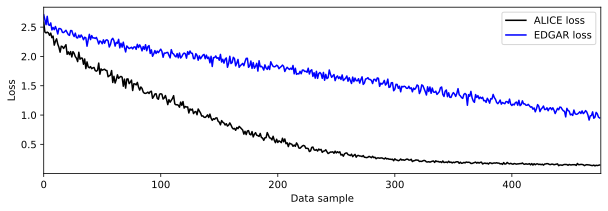

In [15]:
# Graficar las perdidas
plt.figure(figsize=(10,3))
plt.plot(lossAlice,'k',markersize=8,label='ALICE loss')
plt.plot(lossEdgar,'b',markersize=8,label='EDGAR loss')

plt.legend()
plt.gca().set(xlabel='Data sample',ylabel='Loss',xlim=[0,num_samples])
plt.show()

---

* **Análisis de la pérdida de Alice:** La curva de pérdida del modelo de Alicia disminuye de manera pronunciada a medida que avanza el entrenamiento, acercándose fuertemente hacia cero debido al ajuste especializado sobre su corpus literario.


* **Análisis de la pérdida de Edgar:** La pérdida del modelo de Edgar también experimenta una tendencia decreciente constante; sin embargo, esto por sí solo no es necesariamente significativo ni implica automáticamente que el modelo haya adoptado o aprendido plenamente el estilo literario característico de Edgar Allan Poe, ya que la simple reducción de la pérdida refleja la optimización general de los pesos sin garantizar la transferencia estilística profunda.

Antes del entrenamiento :

In [16]:
# Fijar la misma semilla para los tokens posteriores al entrenamiento
torch.manual_seed(42)

# tokens de inicio aleatorios (post-entrenamiento)
randstarts = torch.randint(tokenizer.vocab_size, (numreps, 1)).to(device)

# ALICE: generar y almacenar tokens (post)
outAlice = modelAlice.generate(
    randstarts,
    min_length=numtoks + 1,
    max_length=numtoks + 1,
    do_sample=True,
    pad_token_id=tokenizer.pad_token_id,
).cpu()
genTokensAlice = outAlice[:, 1:].reshape(-1)

# EDGAR: generar y almacenar tokens (post)
outEdgar = modelEdgar.generate(
    randstarts,
    min_length=numtoks + 1,
    max_length=numtoks + 1,
    do_sample=True,
    pad_token_id=tokenizer.pad_token_id,
).cpu()
genTokensEdgar = outEdgar[:, 1:].reshape(-1)

# Calcular los porcentajes post-entrenamiento (fila 1 de la matriz)
tokenUsageAlice[1, 0] = np.mean(100 * np.isin(genTokensAlice, top100Alice))
tokenUsageAlice[1, 1] = np.mean(100 * np.isin(genTokensEdgar, top100Alice))

tokenUsageEdgar[1, 0] = np.mean(100 * np.isin(genTokensAlice, top100Edgar))
tokenUsageEdgar[1, 1] = np.mean(100 * np.isin(genTokensEdgar, top100Edgar))

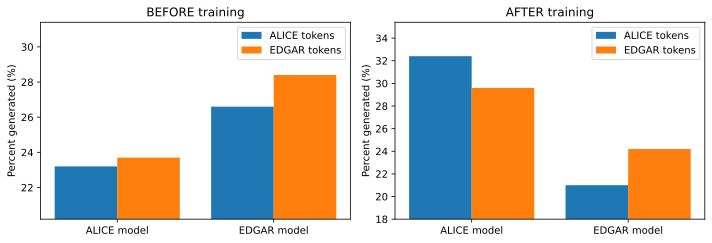

In [18]:
# --- GRÁFICO FINAL DE BARRAS (Con límites automáticos) ---
_, axs = plt.subplots(1, 2, figsize=(10, 3.5))

# ANTES del entrenamiento
axs[0].bar(
    [0.8, 1.8], tokenUsageAlice[0, :], width=0.4, label='ALICE tokens'
)
axs[0].bar(
    [1.2, 2.2], tokenUsageEdgar[0, :], width=0.4, label='EDGAR tokens'
)

minmaxY_pre = np.sort(
    np.concatenate((tokenUsageAlice[0, :], tokenUsageEdgar[0, :]))
)[[0, -1]]
axs[0].set_ylim(minmaxY_pre[0] - 3, minmaxY_pre[1] + 3)
axs[0].set_xticks([1, 2])
axs[0].set_xticklabels(['ALICE model', 'EDGAR model'])
axs[0].set_ylabel('Percent generated (%)')
axs[0].set_title('BEFORE training')
axs[0].legend()

# DESPUÉS del entrenamiento
axs[1].bar(
    [0.8, 1.8], tokenUsageAlice[1, :], width=0.4, label='ALICE tokens'
)
axs[1].bar(
    [1.2, 2.2], tokenUsageEdgar[1, :], width=0.4, label='EDGAR tokens'
)

minmaxY_post = np.sort(
    np.concatenate((tokenUsageAlice[1, :], tokenUsageEdgar[1, :]))
)[[0, -1]]
axs[1].set_ylim(minmaxY_post[0] - 3, minmaxY_post[1] + 3)
axs[1].set_xticks([1, 2])
axs[1].set_xticklabels(['ALICE model', 'EDGAR model'])
axs[1].set_ylabel('Percent generated (%)')
axs[1].set_title('AFTER training')
axs[1].legend()

plt.tight_layout()
plt.show()

---

### **1. ANTES del entrenamiento (BEFORE training)**

* **¿Qué vemos aquí?** Que ambos modelos (el **modelo ALICE** y el **modelo EDGAR**) generan tokens de Alice y tokens de Edgar con porcentajes muy similares y cercanos entre sí.
* **¿Qué significa?** Como los modelos todavía no han sido entrenados específicamente con los textos de los autores, no tienen preferencia real. Esa pequeña diferencia que ves entre las barras no es una especialización, sino producto puramente del **azar**. Representa la magnitud de la variabilidad natural del muestreo aleatorio de la red neuronal.

---

### **2. DESPUÉS del entrenamiento (AFTER training)**

* **¿Qué vemos aquí?** Un cambio radical y completamente opuesto. El **modelo ALICE** dispara drásticamente el porcentaje de tokens de Alice (la barra azul salta a más del 32%), mientras que el **modelo EDGAR** hace lo propio incrementando los tokens de Edgar.
* **¿Qué significa?** ¡El ajuste fino (*fine-tuning*) funcionó a la perfección! Cada modelo aprendió los patrones lingüísticos, el vocabulario y el estilo del autor con el que fue entrenado, sesgando sus predicciones futuras hacia las palabras características de ese texto en particular.

## Evaluación cualitativa

In [20]:
# entrada
x = tokenizer.encode(
    'What did the Red Queen say to Alice?', return_tensors='pt'
).to(device)

# obtener la salida
outAlice = modelAlice.generate(
    x, max_length=50, do_sample=True, pad_token_id=tokenizer.pad_token_id
)
outEdgar = modelEdgar.generate(
    x, max_length=50, do_sample=True, pad_token_id=tokenizer.pad_token_id
)

# imprimir las salidas de ambos modelos
print('** El modelo de Alice dice:')
print(tokenizer.decode(outAlice[0], skip_special_tokens=True))

print('\n\n** El modelo de Edgar dice:')
print(tokenizer.decode(outEdgar[0], skip_special_tokens=True))

** El modelo de Alice dice:
What did the Red Queen say to Alice?”

“She said, “It can’t be!”— but the Queen was reading her history,
somewhere in the wood—�


** El modelo de Edgar dice:
What did the Red Queen say to Alice?—the terrible _Red Death_
      came, with the silver bowstring tied about her neck. She
      raised it, and flatter itself


* **El modelo de Alice:** Responde manteniendo el tono fantástico, los diálogos clásicos y la atmósfera juguetona de *Alicia en el País de las Maravillas* ("somewhere in the wood").

* **El modelo de Edgar:** Fusiona la pregunta de Alicia con elementos oscuros, góticos y lúgubres característicos de la obra de Edgar Allan Poe (como el *Red Death*).

Este contraste demuestra gráficamente cómo el *fine-tuning* logró moldear el comportamiento probabilístico del modelo en muy pocas iteraciones.